# ¿Qué hace realmente un controlador PD?

Antes de agregar modelos, compensaciones o técnicas más sofisticadas, vamos a partir de una pregunta básica:

> **¿Qué puede (y qué no puede) hacer un controlador PD por sí solo?**


---

## Idea central del ensayo

El controlador PD:
- **reacciona al error**,  
- **no anticipa** el movimiento,
- y **no conoce la dinámica del sistema**.

Aun así, es capaz de:
- estabilizar el sistema,
- seguir trayectorias simples,
- y rechazar parcialmente perturbaciones.

La pregunta es **cómo** lo hace y **a qué costo**.

---

## Ensayo propuesto

Vamos a ensayar un movimiento articular muy simple.

La intención no es “poner en aprietos” al controlador, sino observar:
- cómo aparecen los errores,
- cómo evoluciona la acción de control,
- y qué rol juegan las ganancias $K_p$ y $K_d$.

---

## Preguntas para guiar la observación

Durante y después de la simulación, tratá de responder:

- ¿El sistema logra seguir la trayectoria?
- ¿Aparece error estacionario?
- ¿Cómo se comporta el torque cuando el error crece?
- ¿Qué ocurre si aumentamos o disminuimos $K_p$?
- ¿Qué efecto tiene $K_d$ sobre la velocidad y las oscilaciones?

Estas preguntas **no se responden con fórmulas**, sino observando el comportamiento dinámico del sistema.

---

## Objetivo de esta notebook

Al finalizar este ensayo deberías poder responder, con argumentos basados en simulación:

> **Qué tipo de problemas puede resolver un controlador PD,  
> y en qué situaciones comienza a mostrar sus limitaciones.**

Ese será el punto de partida para introducir, en notebooks posteriores,  
modelos, compensaciones y técnicas de control más avanzadas.


In [1]:
from robolib.DoublePendulum import DoublePendulum
import spatialmath as sm
from tqdm import tqdm 
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')


## Simulación de un control PD caso base

In [71]:
dp = DoublePendulum()

# Actualizo algunos términos de la dinámica
dp.links[0].Jm = 1E-4
dp.links[1].Jm = 1E-4
dp.links[0].B = 0.01
dp.links[1].B = 0.01
dp.links[0].G = 10
dp.links[1].G = 10

print(dp)
print(dp.dynamics())

# Determino una trayectoria de referencia
q_dest = np.array([[-np.pi/2, 0.0],[0,np.pi/4],[0,-np.pi/4],[0,0],[0,0]]) 
Tj = np.array([1, 0.5,1,1,1 ])  
POSES_dest = dp.fkine(q_dest)

# Trayectoria JOINT
dp.jtraj(q_dest,Tj);
# Trayectoria CARTESIANA
#dp.ctraj(POSES_dest,Tj);


DHRobot: DoublePendulum, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬──────┬──────────────┬─────────────────────────────┬─────────┬───────┬────────┬─────┐
│   j   │  m   │      r       │              I              │   Jm    │   B   │   Tc   │  G  │
├───────┼──────┼──────────────┼─────────────────────────────┼─────────┼───────┼────────┼─────┤
│ link1 │  1   │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0  │  0.0001 │  0.01 │  0,  0 │  10 │
│ link2 │  1.5 │ -0.1,  0,  0 │  0,  0,  0.0001,  0,  0,  0 │  0.0001 │  0.01 │  0,  0 │  10 │
└───────┴──────┴──────────────┴─────────────────────────────┴─────────┴───────┴────────┴─────┘

None


In [ ]:
def calc_ganancias_control(omega_n, print_results=False):
    # Calculo las ganancias del control PD
    q_test = np.array([0,np.pi/2])  # Caso promedio de inercias 
    mbar = dp.inertia(q_test)

    B = np.diag(np.r_[dp.links[0].B,dp.links[1].B])
    N = np.diag(np.r_[dp.links[0].G,dp.links[1].G])

    Km = 1 
    Jef = np.array([[mbar[0,0],0],[0,mbar[1,1]]])
    Bef = B @ N**2 

    Kp = omega_n**2 * Jef @ np.linalg.inv(Km*N)
    Kd = (2*np.sqrt(Km*N@Kp@Jef)-Bef) @ np.linalg.inv(Km*N)
    if print_results:
        print(f'Kp = {Kp}')
        print(f'Kd = {Kd}')
        print(f'Tiempo de muestreo = {dp.Ts*1000:.2f} ms')
        print(f'Pulsación de muestreo (ws) = {2*np.pi/dp.Ts:.2f} rad/s')
        print(f'Pulsación límite por muestreo = {2*np.pi/dp.Ts/20:.2f} rad/s')

    return Kp,Kd

# Calculo las ganancias del control PD
Kp, Kd = calc_ganancias_control(omega_n=40,print_results=True)

[[0.0961 0.0151]
 [0.0151 0.0251]]
Kp = [[15.376  0.   ]
 [ 0.     4.016]]
Kd = [[0.6688 0.    ]
 [0.     0.1008]]
Tiempo de muestreo = 1.00 ms
Pulsación de muestreo (ws) = 6283.19 rad/s
Pulsación límite por muestreo = 314.16 rad/s


100%|██████████| 3699/3699 [00:14<00:00, 255.10it/s]


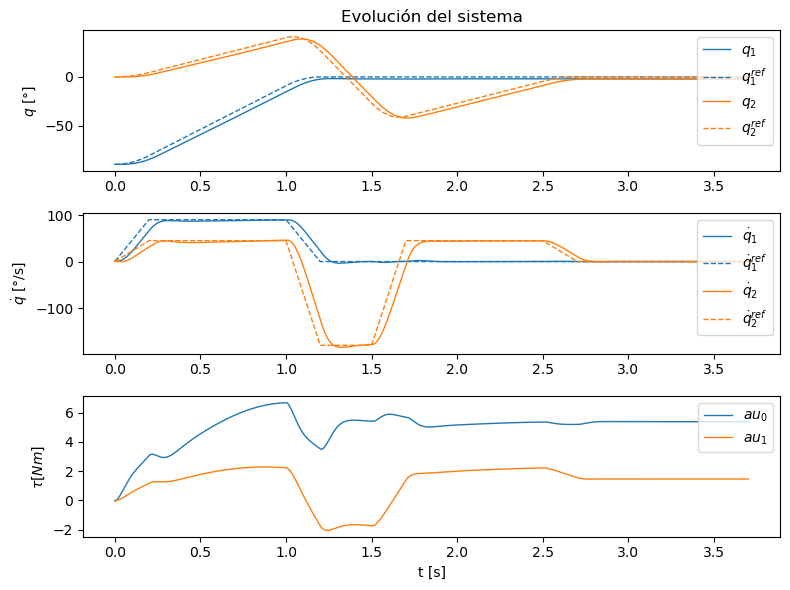

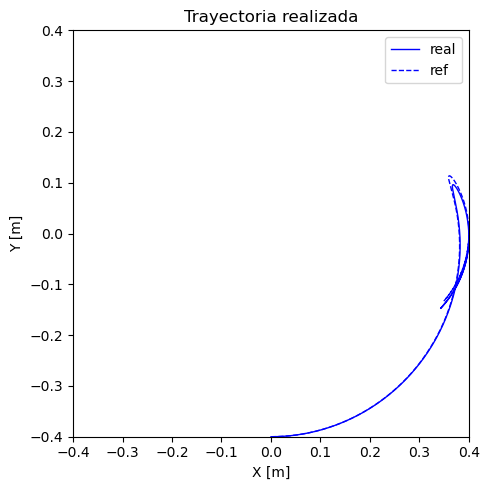

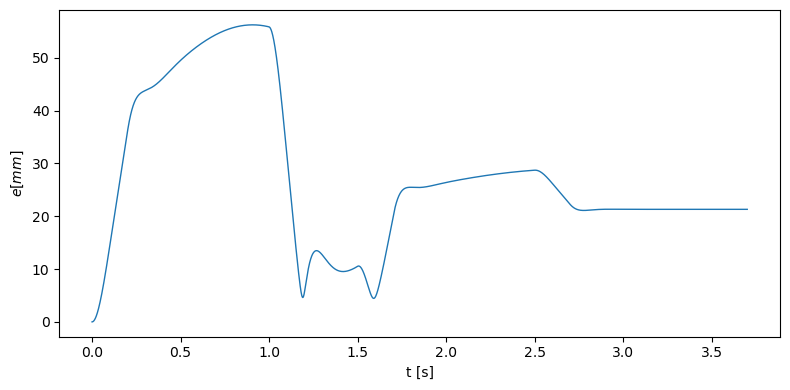

In [73]:
# Parámetros del solver RK45
solver_kwargs = {
    'rtol': 1e-4     # Tolerancia relativa
#    'atol': 1e-8     # Tolerancia absoluta
#    'max_step': 0.1   # Tamaño máximo del paso de integración
}

# Simulación

# Inicializo vectores para simulacion
u = np.zeros_like(dp.q_ref)
q = np.zeros_like(dp.q_ref)
qd = np.zeros_like(dp.qd_ref)

# La condición inicial sale de la primera muestra de las referencias
q[0,:] = dp.q_ref[0,:]
qd[0,:] = dp.qd_ref[0,:]

# Parametros del controlador
umax = 10

# Realizo la simulación 
for idx in tqdm(range(1,len(dp.t_ref))):
  N = np.diag(np.r_[dp.links[0].G,dp.links[1].G])
  # Calculo la ley de control PD
  u[idx,:] = N @ (Kp @ (dp.q_ref[idx]-q[idx-1]) + Kd @ (-qd[idx-1]))
  # Aplico la saturación en la acción de control
  u[idx,:] = np.clip(u[idx,:],-umax,umax)

  tg = dp.nofriction(coulomb=True, viscous=False).fdyn(dp.Ts, 
                                                          q[idx-1],
                                                          qd0=qd[idx-1],
                                                          Q=lambda r, t, q, qd: u[idx],                                                          
                                                          solver_args=solver_kwargs)
  q[idx] = tg.q[-1,:]
  qd[idx] = tg.qd[-1,:]

dp.plot_sim(dp.t_ref,q,qd,dp.t_ref,u)


In [74]:
dp.animate_robot(q,frame_rate=12)

## Evaluamos el efecto de las saturaciones

 53%|█████▎    | 157/299 [00:00<00:00, 303.68it/s]

100%|██████████| 299/299 [00:01<00:00, 254.20it/s]


Text(0.5, 1.0, 'Efecto de las saturaciones')

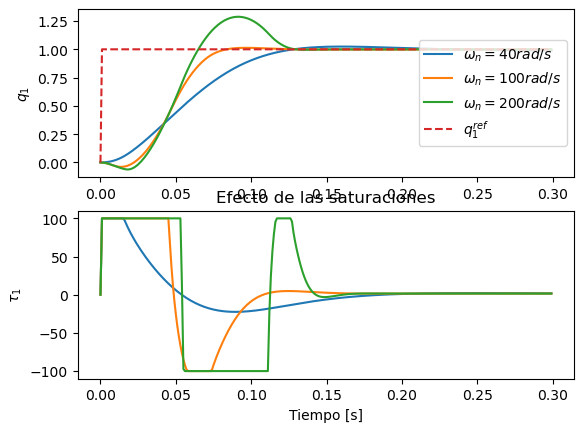

In [75]:
def control_PD(robot,t,q,qd):
    N = np.diag(np.r_[dp.links[0].G,dp.links[1].G])
    _,q_ref,_,_ = dp.get_control_ref(t)
    u = N@(Kp @ (q_ref-q) - Kd @ qd)
    u = np.clip(u,-100,100)
    return u

# Actualizo la referencia a un escalón
dp.t_ref = np.arange(0,0.3,dp.Ts)
dp.q_ref = np.ones((len(dp.t_ref),dp.n))
dp.qd_ref = np.zeros_like(dp.q_ref)
dp.qdd_ref = np.zeros_like(dp.q_ref)
dp.q_ref[0]=np.r_[0,0]

colores = plt.rcParams['axes.prop_cycle'].by_key()['color']        
for idx,omega_n in enumerate([40,100,200]):
    Kp,Kd = calc_ganancias_control(omega_n)
    t,q,qd,u = dp.sim_dis_control(control_PD,solver_kwargs = {'rtol': 1e-6})
    plt.subplot(211)
    plt.plot(t,q[:,0],'-',label=f'$\omega_n={omega_n} rad/s$')
    plt.subplot(212)
    plt.plot(t,u[:,0],'-')
    
plt.subplot(211)    
plt.plot(dp.t_ref,dp.q_ref[:,0],'--',label=f'$q_1^{{ref}}$')
plt.legend(loc='center right')    
plt.ylabel('$q_1$')
plt.subplot(212)    
plt.xlabel('Tiempo [s]')
plt.ylabel('$\\tau_1$')
plt.title('Efecto de las saturaciones')



## Comparación del control de tiempo continuo y de tiempo discreto

Se evalúa el efecto del controlador discreto variando $\omega_n$

100%|██████████| 99/99 [00:00<00:00, 139.83it/s]


100%|██████████| 99/99 [00:00<00:00, 139.67it/s]


100%|██████████| 99/99 [00:00<00:00, 259.02it/s]


100%|██████████| 99/99 [00:01<00:00, 98.86it/s] 


(-0.1, 1.1)

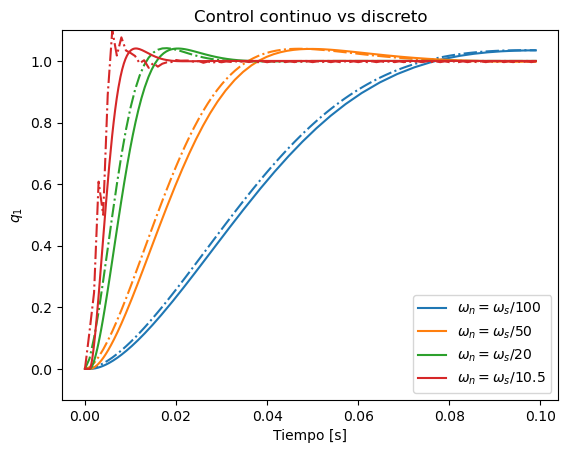

In [85]:
def control_PD(robot,t,q,qd):
    N = np.diag(np.r_[dp.links[0].G,dp.links[1].G])
    _,q_ref,_,_ = dp.get_control_ref(t)
    u = N@(Kp @ (q_ref-q) - Kd @ qd)
    return u

# Actualizo la referencia a un escalón
dp.t_ref = np.arange(0,0.1,dp.Ts)
dp.q_ref = np.ones((len(dp.t_ref),dp.n))
dp.qd_ref = np.zeros_like(dp.q_ref)
dp.qdd_ref = np.zeros_like(dp.q_ref)
dp.q_ref[0]=np.r_[0,0]
omega_s = 2*np.pi/dp.Ts

colores = plt.rcParams['axes.prop_cycle'].by_key()['color']        
for idx,factor in enumerate([100,50,20,10.5]):
    omega_n = omega_s/factor
    Kp,Kd = calc_ganancias_control(omega_n)
    t_dis,q_dis,_,_ = dp.sim_dis_control(control_PD,solver_kwargs={'rtol': 1e-6})
    t_cont,q_cont,_,_ = dp.sim_cont_control(control_PD)

    plt.plot(t_cont,q_cont[:,0],'-',color=colores[idx],label=f'$\omega_n=\omega_s/{factor}$')
    plt.plot(t_dis,q_dis[:,0],'-.',color=colores[idx])  
plt.legend()    
plt.xlabel('Tiempo [s]')
plt.ylabel('$q_1$')
plt.title('Control continuo vs discreto')
plt.ylim((-0.1,1.1))

